### Insights

1. The dataframe has 212 rows, with 7 columns: 
    - `['timestamp', 'distinct_id', 'environment', 'chamber_json', '$geoip_city_name', '$geoip_subdivision_1_code', '$geoip_country_code']`

2. Columns details:
    | Column | Type | Description |
    |:-------|:-----|:------------|
    | `timestamp` | DateTime | Event timestamp (UTC) |
    | `distinct_id` | UUID v7 | Device/Tester ID |
    | `environment` | String | App environment (`testflight`) |
    | `chamber_json` | JSON | Room scan data (nested) |
    | `$geoip_*` | String | Location from IP (city, state, country) |


3. Columns Info:
    - Distinct ID: is UUID-7 format. Probably generated as per UserID/DeviceID.
        - `Unique` Distinct IDs: 21
        - Each `Distinct ID` has around 10 events on average.
        - Top 3 users account for ~58% of all events
    - Timestamp: Ranges from `2026-01-14 18:27 UTC` >> `2026-01-28 16:39 UTC`
    - Environment: was found to have 1 Unique Value, which is `testflight` coming from the `iOS Instant Sketch App`
    - GeoIP Data:
        - `$geoip_city_name`: 29 unique city names.
        - `$geoip_subdivision_1_code`: 25 unique subdivision codes.
        - `$geoip_country_code`: 7 unique country codes.
    - Chamber JSON: Needs further exploration to understand its structure and content.

4. Data Distribution
    - GeoIP Data:
        - 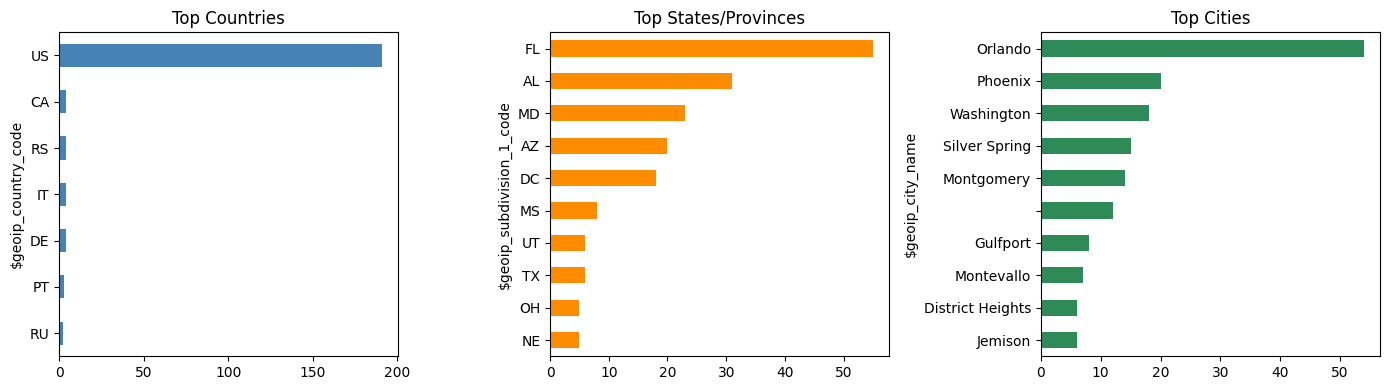
    - Chamber JSON Feature Usage:
        - ![chamber_feature_usage.png](assets/chamber_feature_usage.png)
    - Chamber JSON Value Distribution:
        - ![chamber_value_distribution.png](assets/chamber_value_distribution.png)

### Implementation

In [3]:
from pathlib import Path
import csv
import pandas as pd
from loguru import logger


csv_path = Path.cwd() / "assets" / "export-2026-01-28-104135 (1).csv"

# Use Python's csv module with QUOTE_ALL to handle the nested JSON quotes
rows = []
with open(csv_path, "r", encoding="utf-8") as f:
    reader = csv.reader(f, quotechar='"', doublequote=True)
    headers = next(reader)
    headers = [h.strip() for h in headers]  # Clean whitespace from headers
    for row in reader:
        rows.append(row)

df = pd.DataFrame(rows, columns=headers)

logger.info(f'DF Shape: [{df.shape[0]}, {df.shape[1]}], loaded from "{csv_path}"')
logger.info(f"DF columns: {list(df.columns)}")


2026-01-30 16:29:11.131 | INFO     | __main__:<module>:20 - DF Shape: [212, 7], loaded from "/Users/sheikh/Desktop/SVCC/data-dump-analysis/assets/export-2026-01-28-104135 (1).csv"
2026-01-30 16:29:11.132 | INFO     | __main__:<module>:21 - DF columns: ['timestamp', 'distinct_id', 'environment', 'chamber_json', '$geoip_city_name', '$geoip_subdivision_1_code', '$geoip_country_code']


In [4]:
logger.info(f"Unique Environments: {df['environment'].nunique()}")


2026-01-30 16:29:11.143 | INFO     | __main__:<module>:1 - Unique Environments: 1


In [5]:
logger.info(f"Unique Distinct IDs: {df['distinct_id'].nunique()}")


2026-01-30 16:29:11.151 | INFO     | __main__:<module>:1 - Unique Distinct IDs: 21


In [6]:
logger.info(f"Unique cities: {df['$geoip_city_name'].nunique()}")
logger.info(f"Unique subdivisions: {df['$geoip_subdivision_1_code'].nunique()}")
logger.info(f"Unique countries: {df['$geoip_country_code'].nunique()}")


2026-01-30 16:29:11.158 | INFO     | __main__:<module>:1 - Unique cities: 29
2026-01-30 16:29:11.159 | INFO     | __main__:<module>:2 - Unique subdivisions: 25
2026-01-30 16:29:11.160 | INFO     | __main__:<module>:3 - Unique countries: 7


In [7]:
# Timestamp analysis
df["timestamp"] = pd.to_datetime(df["timestamp"])
df_sorted = df.sort_values("timestamp")
time_diffs = df_sorted["timestamp"].diff()

print(
    f"Range: '{df_sorted['timestamp'].iloc[0]:%Y-%m-%d %H:%M}' → '{df_sorted['timestamp'].iloc[-1]:%Y-%m-%d %H:%M}'",
    f"Total time: ({df_sorted['timestamp'].iloc[-1] - df_sorted['timestamp'].iloc[0]})",
    f"\nIntervals between timestamps:\nmedian {time_diffs.median()},\nmax {time_diffs.max()}",
    sep="\n",
)


Range: '2026-01-14 18:27' → '2026-01-28 16:39'
Total time: (13 days 22:12:21.793000)

Intervals between timestamps:
median 0 days 00:04:12.742000,
max 1 days 02:46:48.845000


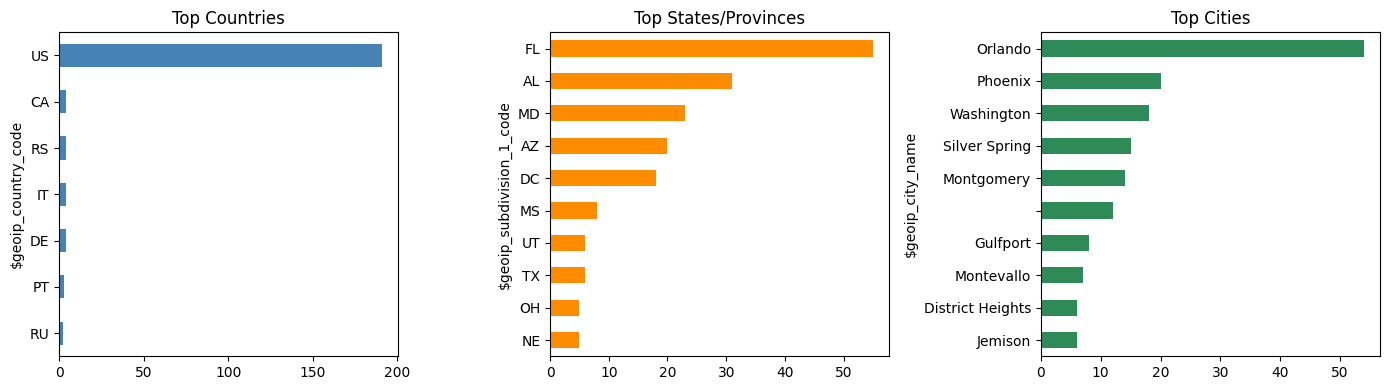

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

df["$geoip_country_code"].value_counts().head(10).plot(
    kind="barh", ax=axes[0], color="steelblue"
)
axes[0].set_title("Top Countries")
axes[0].invert_yaxis()

df["$geoip_subdivision_1_code"].value_counts().head(10).plot(
    kind="barh", ax=axes[1], color="darkorange"
)
axes[1].set_title("Top States/Provinces")
axes[1].invert_yaxis()

df["$geoip_city_name"].value_counts().head(10).plot(
    kind="barh", ax=axes[2], color="seagreen"
)
axes[2].set_title("Top Cities")
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()


## Chamber JSON Analysis

In [9]:
import json

# Parse chamber_json column
df["chamber_parsed"] = df["chamber_json"].apply(json.loads)

# Get top-level keys from first record
sample = df["chamber_parsed"].iloc[0]
print("Top-level keys:", list(sample.keys()))
print("\nSample structure (first record):")
for key, value in sample.items():
    val_type = type(value).__name__
    if isinstance(value, list):
        print(f"  {key}: list[{len(value)}]")
    elif isinstance(value, dict):
        print(
            f"  {key}: dict with keys {list(value.keys())[:5]}{'...' if len(value) > 5 else ''}"
        )
    else:
        print(f"  {key}: {val_type} = {str(value)[:50]}")


Top-level keys: ['roomNames', 'dehumidifierType', 'containmentBarriers', 'id', 'floodCuts', 'wallMoisture', 'capturedRoom', 'freeHandDrawings', 'shapes', 'chamberName', 'layerConfiguration', 'canvasOrigin', 'containToRoom', 'equipment']

Sample structure (first record):
  roomNames: list[0]
  dehumidifierType: str = LGR
  containmentBarriers: list[0]
  id: str = C76A1E68-B006-4142-823B-901464E1BA09
  floodCuts: list[0]
  wallMoisture: list[0]
  capturedRoom: dict with keys ['version', 'floors', 'walls', 'objects', 'openings']...
  freeHandDrawings: list[0]
  shapes: list[0]
  chamberName: str = Basement
  layerConfiguration: dict with keys ['activeLayer', 'layerStates']
  canvasOrigin: dict with keys ['y', 'x']
  containToRoom: bool = True
  equipment: list[0]


In [10]:
# Check key consistency across all records
all_keys = df["chamber_parsed"].apply(lambda x: frozenset(x.keys()))
key_variations = all_keys.value_counts()

print(f"Key structure variations: {len(key_variations)}")
print("\nKey sets (sorted by frequency):")
for keys, count in key_variations.items():
    print(f"  [{count}x] {sorted(keys)}")


Key structure variations: 4

Key sets (sorted by frequency):
  [116x] ['canvasOrigin', 'capturedRoom', 'chamberName', 'containToRoom', 'containmentBarriers', 'dehumidifierType', 'equipment', 'floodCuts', 'freeHandDrawings', 'id', 'layerConfiguration', 'roomNames', 'shapes', 'wallMoisture', 'waterCategory', 'waterClass']
  [87x] ['canvasOrigin', 'capturedRoom', 'chamberName', 'containToRoom', 'containmentBarriers', 'dehumidifierType', 'equipment', 'floodCuts', 'freeHandDrawings', 'id', 'layerConfiguration', 'roomNames', 'shapes', 'wallMoisture']
  [5x] ['canvasOrigin', 'capturedRoom', 'chamberName', 'containToRoom', 'containmentBarriers', 'dehumidifierType', 'equipment', 'floodCuts', 'freeHandDrawings', 'id', 'roomNames', 'shapes', 'wallMoisture']
  [4x] ['canvasOrigin', 'capturedRoom', 'chamberName', 'containToRoom', 'containmentBarriers', 'dehumidifierType', 'equipment', 'floodCuts', 'freeHandDrawings', 'id', 'roomNames', 'shapes', 'wallMoisture', 'waterCategory', 'waterClass']


In [11]:
# Analyze list fields - how many items in each?
list_fields = [
    "equipment",
    "floodCuts",
    "wallMoisture",
    "containmentBarriers",
    "shapes",
    "freeHandDrawings",
    "roomNames",
    # "containToRoom",
    "capturedRoom",
    "chamberName",
    "dehumidifierType",
]

#   containToRoom: bool = True
#   layerConfiguration: dict with keys ['activeLayer', 'layerStates']
#   canvasOrigin: dict with keys ['y', 'x']


print("=== List field sizes across all records ===")
for field in list_fields:
    sizes = df["chamber_parsed"].apply(lambda x: len(x.get(field, [])))
    non_empty = (sizes > 0).sum()
    print(
        f"{field}: {non_empty}/{len(df)} non-empty, max={sizes.max()}, mean={sizes.mean():.1f}"
    )


=== List field sizes across all records ===
equipment: 78/212 non-empty, max=14, mean=2.3
floodCuts: 65/212 non-empty, max=11, mean=1.0
wallMoisture: 29/212 non-empty, max=12, mean=0.7
containmentBarriers: 43/212 non-empty, max=5, mean=0.5
shapes: 55/212 non-empty, max=4, mean=0.4
freeHandDrawings: 10/212 non-empty, max=2, mean=0.1
roomNames: 14/212 non-empty, max=12, mean=0.4
capturedRoom: 212/212 non-empty, max=10, mean=10.0
chamberName: 212/212 non-empty, max=20, mean=18.0
dehumidifierType: 212/212 non-empty, max=3, mean=3.0


In [12]:
# Analyze categorical/scalar fields
print("=== Categorical Fields ===")
print(f"\ndehumidifierType:")
print(df["chamber_parsed"].apply(lambda x: x.get("dehumidifierType")).value_counts())

print(f"\nwaterCategory (120 records have this):")
print(df["chamber_parsed"].apply(lambda x: x.get("waterCategory")).value_counts())

print(f"\nwaterClass (120 records have this):")
print(df["chamber_parsed"].apply(lambda x: x.get("waterClass")).value_counts())

print(f"\nchamberName (room types):")
print(
    df["chamber_parsed"].apply(lambda x: x.get("chamberName")).value_counts().head(15)
)


=== Categorical Fields ===

dehumidifierType:
chamber_parsed
LGR    212
Name: count, dtype: int64

waterCategory (120 records have this):
chamber_parsed
CAT 2          54
CAT 1          44
CAT 3          18
Not defined     4
Name: count, dtype: int64

waterClass (120 records have this):
chamber_parsed
Class 2        63
Class 1        31
Class 3        21
Not defined     4
Class 4         1
Name: count, dtype: int64

chamberName (room types):
chamber_parsed
First Drying Chamber    172
Chamber 1                11
Two bed one bath          7
Chamber 2                 7
Entry                     3
Training Room             2
Kitchen                   2
Den                       2
Basement                  1
Entry                     1
Whole floor               1
Office 1                  1
Ch                        1
Kinda                     1
Name: count, dtype: int64


In [13]:
# Remaining scalar/categorical fields
print("=== Additional Fields ===")

print(f"\ncontainToRoom (bool):")
print(df['chamber_parsed'].apply(lambda x: x.get('containToRoom')).value_counts())

print(f"\nlayerConfiguration.activeLayer:")
print(df['chamber_parsed'].apply(lambda x: x.get('layerConfiguration', {}).get('activeLayer')).value_counts())

print(f"\ncapturedRoom.version:")
print(df['chamber_parsed'].apply(lambda x: x.get('capturedRoom', {}).get('version')).value_counts())

print(f"\ncapturedRoom.story (floor level):")
print(df['chamber_parsed'].apply(lambda x: x.get('capturedRoom', {}).get('story')).value_counts())

# canvasOrigin x,y distribution
canvas_x = df['chamber_parsed'].apply(lambda x: x.get('canvasOrigin', {}).get('x', {}).get('value'))
canvas_y = df['chamber_parsed'].apply(lambda x: x.get('canvasOrigin', {}).get('y', {}).get('value'))
print(f"\ncanvasOrigin.x: min={canvas_x.min()}, max={canvas_x.max()}, unique={canvas_x.nunique()}")
print(f"canvasOrigin.y: min={canvas_y.min()}, max={canvas_y.max()}, unique={canvas_y.nunique()}")


=== Additional Fields ===

containToRoom (bool):
chamber_parsed
True    212
Name: count, dtype: int64

layerConfiguration.activeLayer:
chamber_parsed
moisture     137
equipment     51
floorPlan     15
Name: count, dtype: int64

capturedRoom.version:
chamber_parsed
2    198
1     14
Name: count, dtype: int64

capturedRoom.story (floor level):
chamber_parsed
0    212
Name: count, dtype: int64

canvasOrigin.x: min=5, max=5, unique=1
canvasOrigin.y: min=5, max=5, unique=1


In [14]:
# Analyze capturedRoom structure (the 3D scan data)
sample_room = df["chamber_parsed"].iloc[0]["capturedRoom"]
print("=== capturedRoom structure ===")
print(f"Keys: {list(sample_room.keys())}")

print("\n=== capturedRoom component sizes (all records) ===")
room_components = ["walls", "floors", "doors", "windows", "openings", "objects"]
for comp in room_components:
    sizes = df["chamber_parsed"].apply(lambda x: len(x["capturedRoom"].get(comp, [])))
    non_empty = (sizes > 0).sum()
    print(
        f"{comp}: {non_empty}/{len(df)} non-empty, max={sizes.max()}, mean={sizes.mean():.1f}"
    )


=== capturedRoom structure ===
Keys: ['version', 'floors', 'walls', 'objects', 'openings', 'identifier', 'windows', 'sections', 'doors', 'story']

=== capturedRoom component sizes (all records) ===
walls: 209/212 non-empty, max=55, mean=15.2
floors: 209/212 non-empty, max=1, mean=1.0
doors: 192/212 non-empty, max=13, mean=2.6
windows: 161/212 non-empty, max=11, mean=2.4
openings: 124/212 non-empty, max=5, mean=1.0
objects: 192/212 non-empty, max=69, mean=16.5


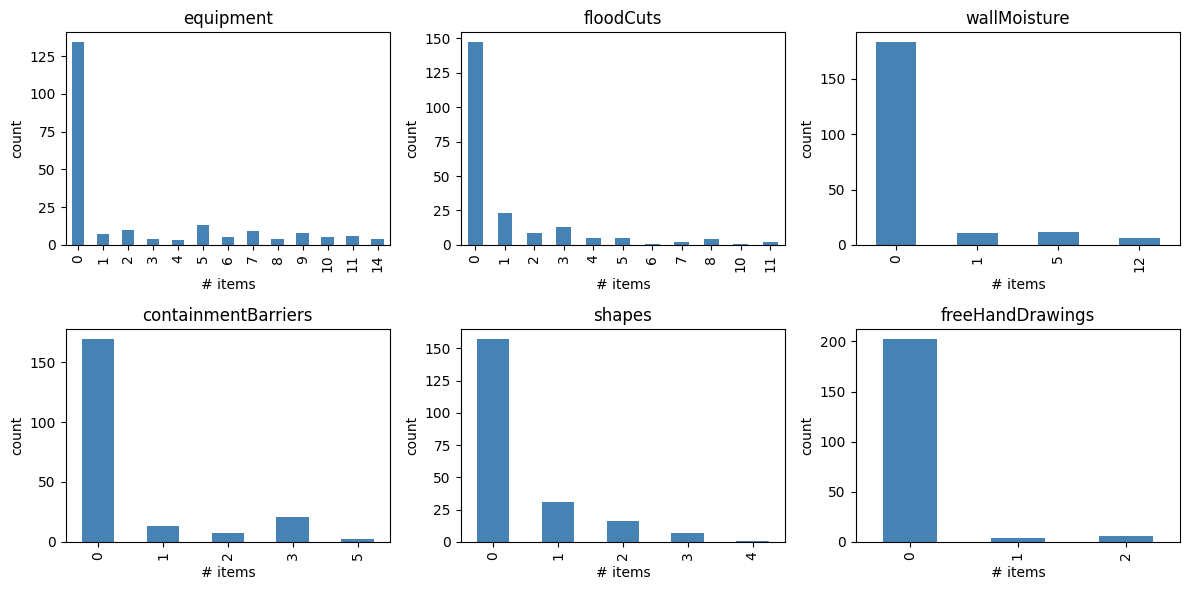

In [15]:
# Distribution of list field sizes
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()

list_fields = [
    "equipment",
    "floodCuts",
    "wallMoisture",
    "containmentBarriers",
    "shapes",
    "freeHandDrawings",
]

for i, field in enumerate(list_fields):
    sizes = df["chamber_parsed"].apply(lambda x: len(x.get(field, [])))
    sizes.value_counts().sort_index().plot(kind="bar", ax=axes[i], color="steelblue")
    axes[i].set_title(f"{field}")
    axes[i].set_xlabel("# items")
    axes[i].set_ylabel("count")

plt.tight_layout()
plt.show()


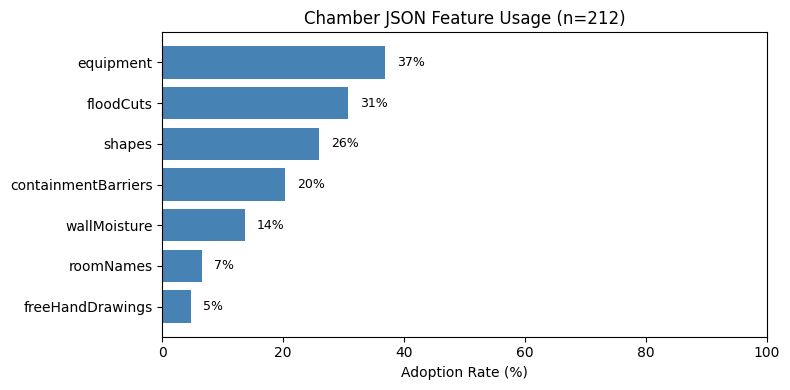

Saved to: assets/chamber_feature_usage.png


In [16]:
# Summary visualization for chamber_json feature usage
fig, ax = plt.subplots(figsize=(8, 4))

list_fields = [
    "equipment",
    "floodCuts",
    "shapes",
    "containmentBarriers",
    "wallMoisture",
    "roomNames",
    "freeHandDrawings",
]
usage_data = []
for field in list_fields:
    sizes = df["chamber_parsed"].apply(lambda x: len(x.get(field, [])))
    non_empty = (sizes > 0).sum()
    usage_data.append(
        {
            "field": field,
            "used": non_empty,
            "empty": len(df) - non_empty,
            "pct": non_empty / len(df) * 100,
        }
    )

usage_df = pd.DataFrame(usage_data).sort_values("pct", ascending=True)

bars = ax.barh(usage_df["field"], usage_df["pct"], color="steelblue")
ax.set_xlabel("Adoption Rate (%)")
ax.set_title("Chamber JSON Feature Usage (n=212)")
ax.set_xlim(0, 100)

# Add percentage labels
for bar, pct in zip(bars, usage_df["pct"]):
    ax.text(
        pct + 2,
        bar.get_y() + bar.get_height() / 2,
        f"{pct:.0f}%",
        va="center",
        fontsize=9,
    )

plt.tight_layout()
plt.savefig("assets/chamber_feature_usage.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to: assets/chamber_feature_usage.png")


In [17]:
# Extract and examine values inside each list field
def get_all_items(field):
    """Flatten all items from a list field across all records"""
    items = []
    for parsed in df["chamber_parsed"]:
        items.extend(parsed.get(field, []))
    return items


# Show structure of first item in each non-empty field
list_fields = [
    "equipment",
    "floodCuts",
    "wallMoisture",
    "containmentBarriers",
    "shapes",
    "roomNames",
    "freeHandDrawings",
]

for field in list_fields:
    items = get_all_items(field)
    if items:
        print(f"\n{'=' * 50}")
        print(f"{field.upper()} ({len(items)} total items)")
        print(f"{'=' * 50}")
        sample = items[0]
        if isinstance(sample, dict):
            print(f"Keys: {list(sample.keys())}")
            # Show unique values for key fields if they exist
            for key in ["type", "category", "name", "equipmentType"]:
                if key in sample:
                    unique_vals = set(
                        item.get(key) for item in items if isinstance(item, dict)
                    )
                    print(f"  {key} values: {unique_vals}")
        else:
            print(f"Type: {type(sample).__name__}, Sample: {sample}")



EQUIPMENT (485 total items)
Keys: ['rotation', 'position', 'id', 'type']
  type values: {'Air Scrubber', 'Air Mover', 'dehumidifier'}

FLOODCUTS (209 total items)
Keys: ['positionAlongWall', 'isWholeWall', 'wallId', 'lengthAlongWall', 'doorwayRanges', 'id', 'heightInFeet']

WALLMOISTURE (143 total items)
Keys: ['wallId', 'moistureHeightAbove2Ft', 'positionAlongWall', 'lengthAlongWall', 'id', 'doorwayRanges', 'isWholeWall']

CONTAINMENTBARRIERS (100 total items)
Keys: ['endPositionAlongWall', 'startPositionAlongWall', 'note', 'id', 'startWallId', 'endWallId', 'barrierType']

SHAPES (88 total items)
Keys: ['affectedSurfaces', 'center', 'size', 'vertices', 'type', 'id', 'shapeType']
  type values: {'moistureArea'}

ROOMNAMES (76 total items)
Type: str, Sample: A4AAF93F-E5EB-487C-9E72-D5EE57D60D8C

FREEHANDDRAWINGS (16 total items)
Keys: ['isClosed', 'affectedSurfaces', 'id', 'type', 'points']
  type values: {'moistureArea'}


In [18]:
# Detailed value counts for key fields
from collections import Counter

print("=== EQUIPMENT TYPES ===")
equipment_items = get_all_items("equipment")
if equipment_items and isinstance(equipment_items[0], dict):
    # Try common key names for type
    for key in ["equipmentType", "type", "name", "category"]:
        types = [item.get(key) for item in equipment_items if item.get(key)]
        if types:
            print(f"\n{key}:")
            for val, count in Counter(types).most_common():
                print(f"  {val}: {count}")
            break

print("\n=== SHAPES TYPES ===")
shape_items = get_all_items("shapes")
if shape_items and isinstance(shape_items[0], dict):
    for key in ["type", "shapeType", "name"]:
        types = [item.get(key) for item in shape_items if item.get(key)]
        if types:
            print(f"\n{key}:")
            for val, count in Counter(types).most_common():
                print(f"  {val}: {count}")
            break

print("\n=== CONTAINMENT BARRIER TYPES ===")
barrier_items = get_all_items("containmentBarriers")
if barrier_items and isinstance(barrier_items[0], dict):
    for key in ["type", "barrierType", "name"]:
        types = [item.get(key) for item in barrier_items if item.get(key)]
        if types:
            print(f"\n{key}:")
            for val, count in Counter(types).most_common():
                print(f"  {val}: {count}")
            break


=== EQUIPMENT TYPES ===

type:
  Air Mover: 324
  dehumidifier: 81
  Air Scrubber: 80

=== SHAPES TYPES ===

type:
  moistureArea: 88

=== CONTAINMENT BARRIER TYPES ===

barrierType:
  wallToWall: 59
  doorwaySpan: 41


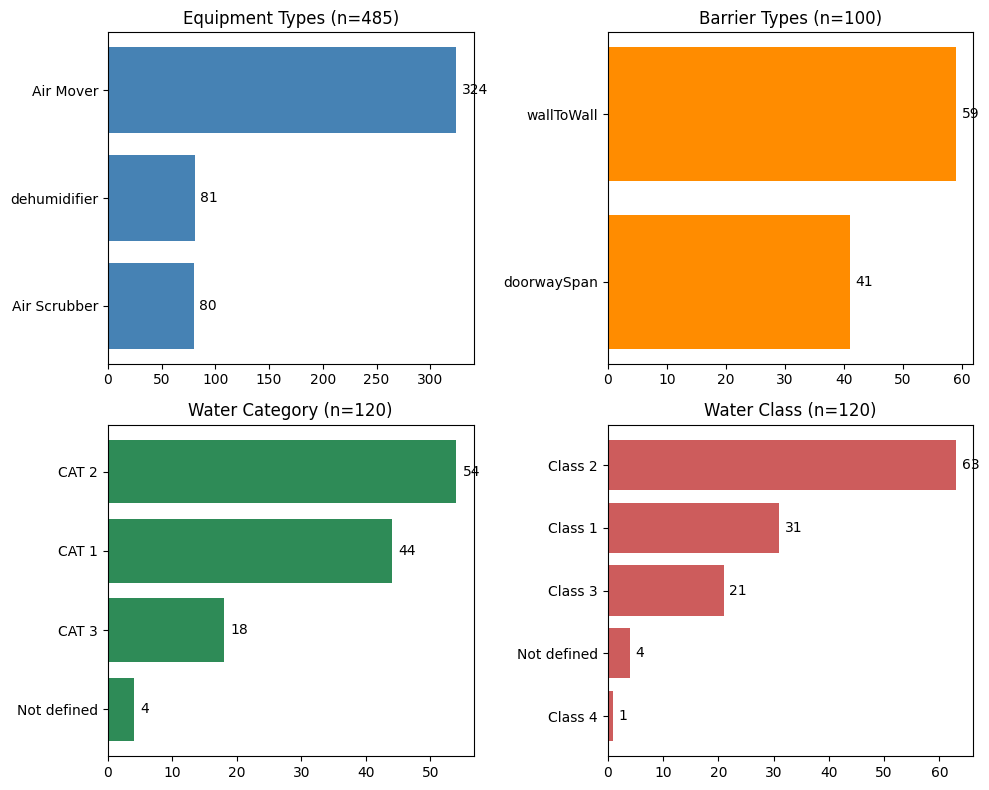

Saved to: assets/chamber_value_distribution.png


In [19]:
# Distribution of values within each chamber_json field
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Equipment Types
equipment_types = [
    item.get("type") for item in get_all_items("equipment") if item.get("type")
]
eq_counts = pd.Series(equipment_types).value_counts()
axes[0, 0].barh(eq_counts.index, eq_counts.values, color="steelblue")
axes[0, 0].set_title(f"Equipment Types (n={len(equipment_types)})")
axes[0, 0].invert_yaxis()
for i, v in enumerate(eq_counts.values):
    axes[0, 0].text(v + 5, i, str(v), va="center")

# Containment Barrier Types
barrier_types = [
    item.get("barrierType")
    for item in get_all_items("containmentBarriers")
    if item.get("barrierType")
]
bar_counts = pd.Series(barrier_types).value_counts()
axes[0, 1].barh(bar_counts.index, bar_counts.values, color="darkorange")
axes[0, 1].set_title(f"Barrier Types (n={len(barrier_types)})")
axes[0, 1].invert_yaxis()
for i, v in enumerate(bar_counts.values):
    axes[0, 1].text(v + 1, i, str(v), va="center")

# Water Category
water_cats = df["chamber_parsed"].apply(lambda x: x.get("waterCategory")).dropna()
wc_counts = water_cats.value_counts()
axes[1, 0].barh(wc_counts.index, wc_counts.values, color="seagreen")
axes[1, 0].set_title(f"Water Category (n={len(water_cats)})")
axes[1, 0].invert_yaxis()
for i, v in enumerate(wc_counts.values):
    axes[1, 0].text(v + 1, i, str(v), va="center")

# Water Class
water_class = df["chamber_parsed"].apply(lambda x: x.get("waterClass")).dropna()
wcl_counts = water_class.value_counts()
axes[1, 1].barh(wcl_counts.index, wcl_counts.values, color="indianred")
axes[1, 1].set_title(f"Water Class (n={len(water_class)})")
axes[1, 1].invert_yaxis()
for i, v in enumerate(wcl_counts.values):
    axes[1, 1].text(v + 1, i, str(v), va="center")

plt.tight_layout()
plt.savefig("assets/chamber_value_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to: assets/chamber_value_distribution.png")


In [20]:
# Investigate "Not defined" water category and class
df["waterCategory"] = df["chamber_parsed"].apply(lambda x: x.get("waterCategory"))
df["waterClass"] = df["chamber_parsed"].apply(lambda x: x.get("waterClass"))

# Records with "Not defined"
not_defined_cat = df[df["waterCategory"] == "Not defined"]
not_defined_class = df[df["waterClass"] == "Not defined"]

print(f"=== Records with 'Not defined' Water Category ({len(not_defined_cat)}) ===")
print(
    not_defined_cat[
        ["timestamp", "distinct_id", "waterCategory", "waterClass"]
    ].to_string(index=False)
)

print(f"\n=== Records with 'Not defined' Water Class ({len(not_defined_class)}) ===")
print(
    not_defined_class[
        ["timestamp", "distinct_id", "waterCategory", "waterClass"]
    ].to_string(index=False)
)

# Are they the same records?
print(f"\n=== Overlap ===")
print(f"Same records? {set(not_defined_cat.index) == set(not_defined_class.index)}")

# What testers have "Not defined"?
print(f"\n=== Testers with 'Not defined' ===")
print(not_defined_cat["distinct_id"].value_counts())


=== Records with 'Not defined' Water Category (4) ===
                       timestamp                          distinct_id waterCategory  waterClass
2026-01-21 16:04:25.573000+00:00 019BC706-A9EB-742F-87C5-E562D408C327   Not defined Not defined
2026-01-21 16:04:13.977000+00:00 019BC706-A9EB-742F-87C5-E562D408C327   Not defined Not defined
2026-01-21 16:03:57.005000+00:00 019BC706-A9EB-742F-87C5-E562D408C327   Not defined Not defined
2026-01-21 16:03:28.797000+00:00 019BC706-A9EB-742F-87C5-E562D408C327   Not defined Not defined

=== Records with 'Not defined' Water Class (4) ===
                       timestamp                          distinct_id waterCategory  waterClass
2026-01-21 16:04:25.573000+00:00 019BC706-A9EB-742F-87C5-E562D408C327   Not defined Not defined
2026-01-21 16:04:13.977000+00:00 019BC706-A9EB-742F-87C5-E562D408C327   Not defined Not defined
2026-01-21 16:03:57.005000+00:00 019BC706-A9EB-742F-87C5-E562D408C327   Not defined Not defined
2026-01-21 16:03:28.797000+00:

In [21]:
# Find the largest (fattest) chamber_json object
df["json_size"] = df["chamber_json"].apply(len)

largest_idx = df["json_size"].idxmax()
largest_row = df.loc[largest_idx]

print(f"=== Largest JSON Object ===")
print(f"Size: {largest_row['json_size']:,} characters")
print(f"Timestamp: {largest_row['timestamp']}")
print(f"Tester ID: {largest_row['distinct_id']}")

# Show stats
print(f"\n=== JSON Size Stats ===")
print(f"Min: {df['json_size'].min():,} chars")
print(f"Max: {df['json_size'].max():,} chars")
print(f"Mean: {df['json_size'].mean():,.0f} chars")
print(f"Median: {df['json_size'].median():,.0f} chars")

# Show content breakdown of the largest
largest_parsed = largest_row["chamber_parsed"]
print(f"\n=== Largest JSON Content Breakdown ===")
for key, value in largest_parsed.items():
    if isinstance(value, list):
        print(f"  {key}: {len(value)} items")
    elif isinstance(value, dict):
        print(f"  {key}: dict with {len(value)} keys")
    else:
        print(f"  {key}: {type(value).__name__}")


=== Largest JSON Object ===
Size: 48,509 characters
Timestamp: 2026-01-28 13:44:58.401000+00:00
Tester ID: 019BC480-28ED-76C8-B4A7-6F762054F432

=== JSON Size Stats ===
Min: 726 chars
Max: 48,509 chars
Mean: 15,911 chars
Median: 12,995 chars

=== Largest JSON Content Breakdown ===
  equipment: 0 items
  canvasOrigin: dict with 2 keys
  id: str
  containmentBarriers: 0 items
  roomNames: 0 items
  freeHandDrawings: 0 items
  dehumidifierType: str
  shapes: 0 items
  chamberName: str
  wallMoisture: 0 items
  capturedRoom: dict with 10 keys
  floodCuts: 0 items
  containToRoom: bool
  layerConfiguration: dict with 2 keys


In [22]:
# Find the most "complete" JSON (most non-empty fields)
def count_filled_fields(parsed):
    score = 0
    list_fields = ['equipment', 'floodCuts', 'wallMoisture', 'containmentBarriers', 'shapes', 'freeHandDrawings', 'roomNames']
    for field in list_fields:
        if len(parsed.get(field, [])) > 0:
            score += len(parsed.get(field, []))
    # Bonus for having waterCategory/waterClass
    if parsed.get('waterCategory') and parsed.get('waterCategory') != 'Not defined':
        score += 5
    if parsed.get('waterClass') and parsed.get('waterClass') != 'Not defined':
        score += 5
    return score

df['completeness_score'] = df['chamber_parsed'].apply(count_filled_fields)
most_complete_idx = df['completeness_score'].idxmax()
most_complete = df.loc[most_complete_idx, 'chamber_parsed']

print(f"Most complete record (score: {df.loc[most_complete_idx, 'completeness_score']})")
print(f"Tester: {df.loc[most_complete_idx, 'distinct_id']}")
print(f"Timestamp: {df.loc[most_complete_idx, 'timestamp']}")
print(f"\n{'='*60}")

# Pretty print the JSON
import json
print(json.dumps(most_complete, indent=2))


Most complete record (score: 35)
Tester: 019B8E69-47F1-7763-A141-99AEB40BEB39
Timestamp: 2026-01-20 23:42:51.001000+00:00

{
  "canvasOrigin": {
    "x": {
      "value": 5
    },
    "y": {
      "value": 5
    }
  },
  "equipment": [
    {
      "id": "778CA288-DB39-4F47-85C6-DA1A9249920E",
      "position": {
        "y": {
          "value": 3.070903778076172
        },
        "x": {
          "value": 7.250472068786621
        }
      },
      "type": "Air Mover",
      "rotation": 0
    },
    {
      "id": "82076042-E07D-4695-98BD-8F05048A5954",
      "position": {
        "y": {
          "value": 5.441545009613037
        },
        "x": {
          "value": 5.706352531909943
        }
      },
      "type": "Air Mover",
      "rotation": 0
    },
    {
      "id": "93A3962A-79E4-4A13-8CAC-3ECBF55FAB3A",
      "position": {
        "y": {
          "value": 4.788016766309738
        },
        "x": {
          "value": 4.143011450767517
        }
      },
      "type": "Air M

In [23]:
# Find the row matching the PDF: First_Drying_Chamber_2026-01-28_121556.pdf
# Search by timestamp closest to 2026-01-28 12:15:56

df['ts'] = pd.to_datetime(df['timestamp'])
target = pd.Timestamp('2026-01-28 12:15:56', tz='UTC')
df['time_diff'] = abs(df['ts'] - target)
closest_idx = df['time_diff'].idxmin()
closest_row = df.loc[closest_idx]

# Store in variable
pdf_json = closest_row['chamber_parsed']

print(f"=== Matched Record ===")
print(f"Timestamp: {closest_row['timestamp']}")
print(f"Tester ID: {closest_row['distinct_id']}")
print(f"Chamber: {pdf_json.get('chamberName')}")
print(f"Water Class: {pdf_json.get('waterClass')}, Category: {pdf_json.get('waterCategory')}")
print(f"\nJSON stored in variable: pdf_json")


=== Matched Record ===
Timestamp: 2026-01-28 13:00:05.144000+00:00
Tester ID: 019BD681-4E4F-76A8-B39D-E9EE254E9654
Chamber: First Drying Chamber
Water Class: None, Category: None

JSON stored in variable: pdf_json


In [24]:
pdf_json  # view it


{'canvasOrigin': {'x': {'value': 5}, 'y': {'value': 5}},
 'containToRoom': True,
 'capturedRoom': {'sections': [{'label': 'unidentified',
    'story': 0,
    'center': [-6.6480412, 0.1270015, -1.8156037]},
   {'label': 'unidentified',
    'story': 0,
    'center': [0.24123862, 0.1270015, 0.2791362]},
   {'label': 'bathroom',
    'story': 0,
    'center': [-1.7072246, 0.1270015, 0.54687846]}],
  'story': 0,
  'windows': [{'transform': [0.1073983,
     0,
     0.9942161,
     0,
     0,
     1.0000001,
     0,
     0,
     -0.9942161,
     0,
     0.10739831,
     0,
     1.3807428,
     0.5004148,
     -1.4451269,
     1],
    'story': 0,
    'parentIdentifier': '8729B350-A391-4F9A-9C88-791C1D7325F4',
    'confidence': {'medium': {}},
    'identifier': 'EADB098F-55EE-4B73-88E1-8A623A91264C',
    'completedEdges': [],
    'dimensions': [0.63301694, 1.113194, 0],
    'polygonCorners': [],
    'category': {'window': {}}}],
  'objects': [{'story': 0,
    'identifier': 'B4945F37-C071-4050-83

In [ ]:
from shapely.geometry import Polygon

# Extract x,y coordinates (ignoring z which is always 0)
polygon_corners = [
    (-5.6295137, -4.039828),
    (-5.6292295, -3.4937348),
    (-5.9167633, 3.4622428),
    (-5.595093, 3.4620755),
    (-5.5947886, 4.0436964),
    (0.632751, 4.040449),
    (1.468049, 4.0400143),
    (1.4680026, 3.9510252),
    (5.9167633, 3.948706),
    (5.9134774, -2.3533225),
    (5.9125967, -4.042048),
    (3.2495189, -4.04066),
    (1.7815981, -4.043695),
]

floor_polygon = Polygon(polygon_corners)

# Calculate area
area_m2 = floor_polygon.area
area_sqft = area_m2 * 10.7639

print(f"Area: {area_m2:.2f} m² = {area_sqft:.2f} sq ft")
print(f"Is valid: {floor_polygon.is_valid}")
print(f"Perimeter: {floor_polygon.length:.2f} m")


Area: 93.89 m² = 1010.59 sq ft
Is valid: True
Perimeter: 39.54 m


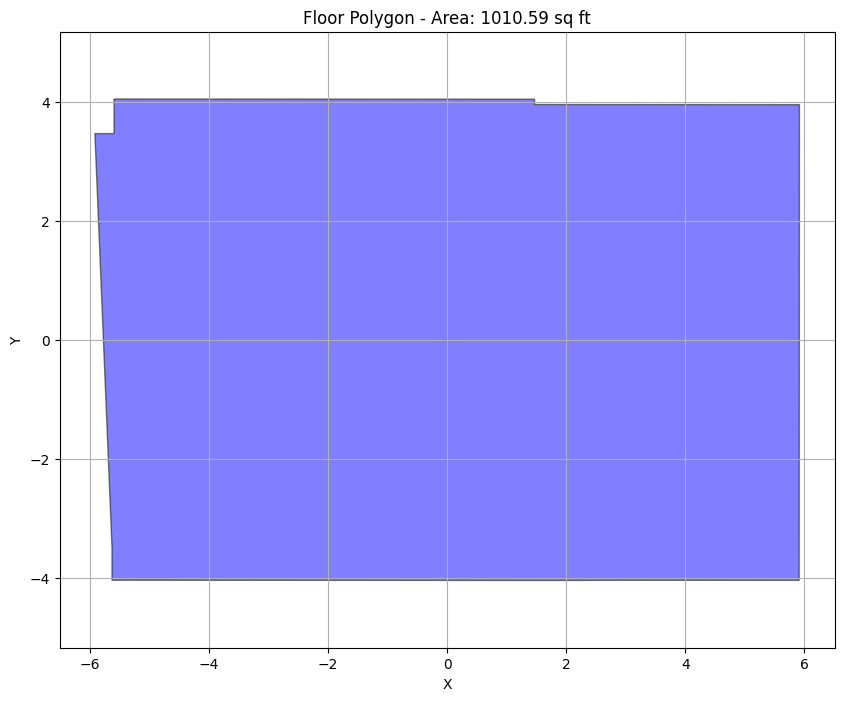

In [26]:
import matplotlib.pyplot as plt

x, y = floor_polygon.exterior.xy
plt.figure(figsize=(10, 8))
plt.fill(x, y, alpha=0.5, fc="blue", ec="black")
plt.axis("equal")
plt.grid(True)
plt.title(f"Floor Polygon - Area: {area_sqft:.2f} sq ft")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()
